## Importing the required libraries 

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


## Loading the Data Set

In [2]:
train_dir = "Data set/Training"
test_dir  = "Data set/Testing"

Visualizing the Training Data set

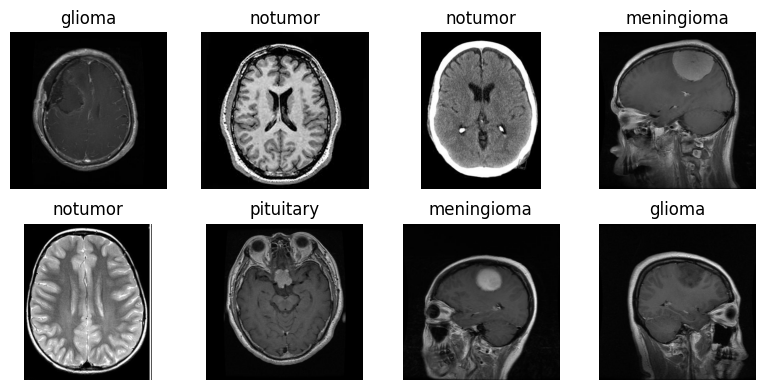

In [3]:
import random
rows, cols = 2,4

image_list = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            image_list.append((class_name, os.path.join(class_path, img_name)))

sample_images = random.sample(image_list, rows * cols)

plt.figure(figsize=(8,4))

for i, (label, img_path) in enumerate(sample_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()


Visualizing the Testing Data set

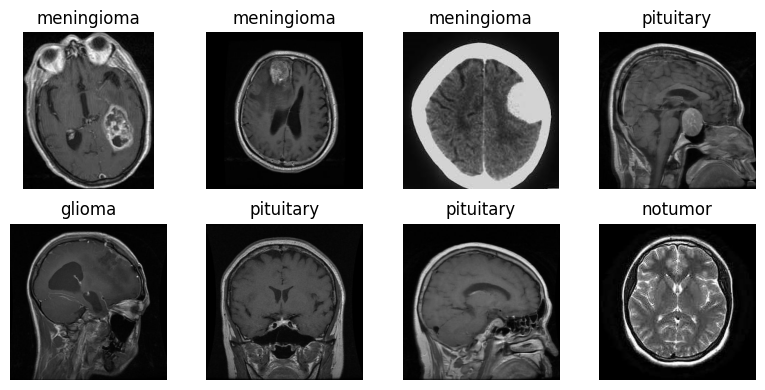

In [4]:
rows, cols = 2,4

image_list = []

for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            image_list.append((class_name, os.path.join(class_path, img_name)))

sample_images = random.sample(image_list, rows * cols)

plt.figure(figsize=(8,4))

for i, (label, img_path) in enumerate(sample_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()


## Configuration Parameters

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 15


## Data Preprocessing & Augmentation

In [9]:
#for training
train_datagen = ImageDataGenerator(rescale = 1./225,
                                   rotation_range = 15,
                                   zoom_range = 0.1,
                                   horizontal_flip = True)
#for testing
test_datagen = ImageDataGenerator(rescale = 1./225)

train_gen = train_datagen.flow_from_directory(train_dir,
                                              target_size=(IMG_SIZE, IMG_SIZE),
                                              batch_size=BATCH_SIZE,
                                              class_mode="categorical")

test_gen = test_datagen.flow_from_directory(test_dir,
                                            target_size=(IMG_SIZE,IMG_SIZE),
                                            batch_size=BATCH_SIZE,
                                            class_mode="categorical",
                                            shuffle=False)

class_names=list(train_gen.class_indices.keys())
print(class_names)

Found 5712 images belonging to 4 classes.
Found 1315 images belonging to 4 classes.
['glioma', 'meningioma', 'notumor', 'pituitary']


# Training the CNN Models

## Model-1 ResNet50

In [10]:
from tensorflow.keras.applications import ResNet50
resnet_base=ResNet50(weights="imagenet", include_top=False,
                    input_shape=(224,224,3))
resnet_base.trainable=False
x=resnet_base.output
x=GlobalAveragePooling2D()(x)
x=Dense(256, activation="relu")(x)
output=Dense(NUM_CLASSES, activation="softmax")(x)
resnet_model=Model(resnet_base.input,output)
resnet_model.compile(optimizer=Adam(0.0001),
                     loss="categorical_crossentropy",
                     metrics=["accuracy"])

history_resnet=resnet_model.fit(train_gen,epochs=EPOCHS,
                                validation_data=test_gen)

Epoch 1/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 514s 3s/step - accuracy: 0.4974 - loss: 1.1764 - val_accuracy: 0.5308 - val_loss: 1.1253
Epoch 2/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 481s 3s/step - accuracy: 0.6555 - loss: 0.9582 - val_accuracy: 0.5894 - val_loss: 1.0405
Epoch 4/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 466s 3s/step - accuracy: 0.6633 - loss: 0.9113 - val_accuracy: 0.6243 - val_loss: 0.9820
Epoch 5/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 463s 3s/step - accuracy: 0.6677 - loss: 0.8738 - val_accuracy: 0.6228 - val_loss: 0.9811
Epoch 6/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 457s 3s/step - accuracy: 0.6742 - loss: 0.8483 - val_accuracy: 0.6304 - val_loss: 0.9628
Epoch 7/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 456s 3s/step - accuracy: 0.6871 - loss: 0.8214 - val_accuracy: 0.6532 - val_loss: 0.9268
Epoch 8/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 500s 3s/step - accuracy: 0.6952 - loss: 0.7928 - val_accuracy: 0.6593 - val_loss: 0.8839
Epoch 9/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 551s 3s/step - accuracy: 0.7031 - loss: 0.7780 - val_accu

## Model-2 DenseNet121

In [11]:
from tensorflow.keras.applications import DenseNet121

dense_base = DenseNet121(weights="imagenet", include_top=False,
                         input_shape=(224,224,3))
dense_base.trainable = False

x = dense_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

densenet_model = Model(dense_base.input, output)

densenet_model.compile(optimizer=Adam(0.0001),
                       loss="categorical_crossentropy",
                       metrics=["accuracy"])

history_densenet = densenet_model.fit(train_gen,epochs=EPOCHS,
                                      validation_data=test_gen)


Epoch 1/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 460s 2s/step - accuracy: 0.7495 - loss: 0.7067 - val_accuracy: 0.7932 - val_loss: 0.5822
Epoch 2/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 422s 2s/step - accuracy: 0.8659 - loss: 0.4127 - val_accuracy: 0.8183 - val_loss: 0.4856
Epoch 3/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 423s 2s/step - accuracy: 0.8876 - loss: 0.3455 - val_accuracy: 0.8608 - val_loss: 0.4077
Epoch 4/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 444s 2s/step - accuracy: 0.8939 - loss: 0.3045 - val_accuracy: 0.8677 - val_loss: 0.3747
Epoch 5/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 466s 3s/step - accuracy: 0.9035 - loss: 0.2820 - val_accuracy: 0.8365 - val_loss: 0.4033
Epoch 6/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 442s 2s/step - accuracy: 0.9081 - loss: 0.2677 - val_accuracy: 0.8570 - val_loss: 0.3492
Epoch 7/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 451s 3s/step - accuracy: 0.9160 - loss: 0.2466 - val_accuracy: 0.8783 - val_loss: 0.3220
Epoch 8/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 434s 2s/step - accuracy: 0.9174 - loss: 0.2349 - val_accu

## Model-3 EfficientNetB0

In [12]:
from tensorflow.keras.applications import EfficientNetB0
eff_base = EfficientNetB0(weights= "imagenet", include_top=False,
                          input_shape=(224,224,3))
eff_base.trainable= False
x = eff_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation ="relu")(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)
efficientnet_model = Model(eff_base.input, output)
efficientnet_model.compile(optimizer=Adam(0.0001),
                        loss="categorical_crossentropy",
                        metrics=["accuracy"])
history_efficientnet= efficientnet_model.fit(train_gen,
                                             epochs=EPOCHS,
                                             validation_data=test_gen)

Epoch 1/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.2770 - loss: 1.3864 - val_accuracy: 0.2342 - val_loss: 1.3869
Epoch 2/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.2939 - loss: 1.3815 - val_accuracy: 0.2433 - val_loss: 1.3856
Epoch 3/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.2936 - loss: 1.3782 - val_accuracy: 0.3361 - val_loss: 1.3742
Epoch 4/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.2932 - loss: 1.3759 - val_accuracy: 0.3080 - val_loss: 1.3645
Epoch 5/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.3116 - loss: 1.3717 - val_accuracy: 0.3087 - val_loss: 1.3581
Epoch 6/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.3141 - loss: 1.3672 - val_accuracy: 0.3087 - val_loss: 1.3625
Epoch 7/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - accuracy: 0.3202 - loss: 1.3653 - val_accuracy: 0.3004 - val_loss: 1.3662
Epoch 8/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.3088 - loss: 1.3619 - val_accu

## Model Evaluation

42/42 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step

ResNet50 Classification_report
              precision    recall  f1-score   support

      glioma       0.69      0.50      0.58       302
  meningioma       0.51      0.46      0.48       306
     notumor       0.79      0.85      0.82       406
   pituitary       0.69      0.89      0.78       301

    accuracy                           0.69      1315
   macro avg       0.67      0.67      0.67      1315
weighted avg       0.68      0.69      0.68      1315



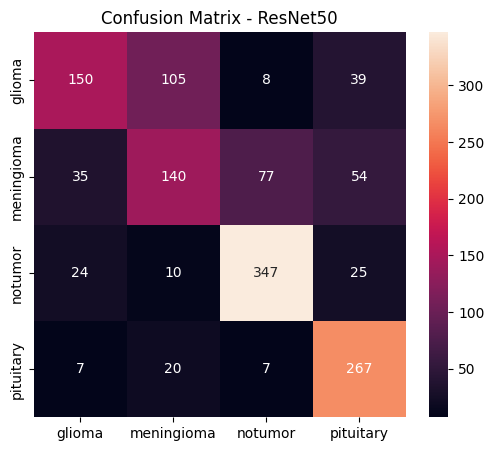

42/42 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step

DenseNet121 Classification_report
              precision    recall  f1-score   support

      glioma       0.91      0.87      0.89       302
  meningioma       0.85      0.71      0.77       306
     notumor       0.90      0.98      0.94       406
   pituitary       0.90      0.98      0.94       301

    accuracy                           0.89      1315
   macro avg       0.89      0.89      0.89      1315
weighted avg       0.89      0.89      0.89      1315



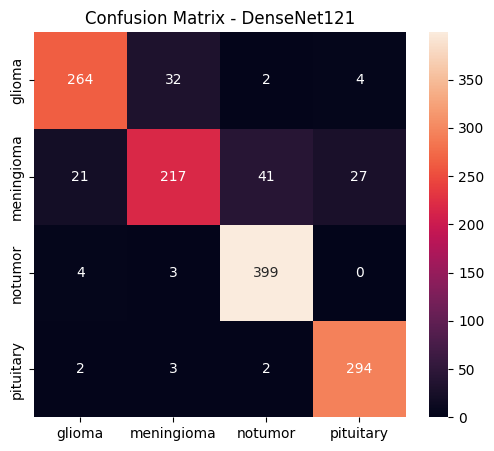

42/42 ━━━━━━━━━━━━━━━━━━━━ 38s 750ms/step

EffienetNetB0 Classification_report
              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       302
  meningioma       0.00      0.00      0.00       306
     notumor       0.79      0.29      0.43       406
   pituitary       0.26      1.00      0.41       301

    accuracy                           0.32      1315
   macro avg       0.26      0.32      0.21      1315
weighted avg       0.30      0.32      0.23      1315



C:\Users\marat\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\marat\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\marat\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

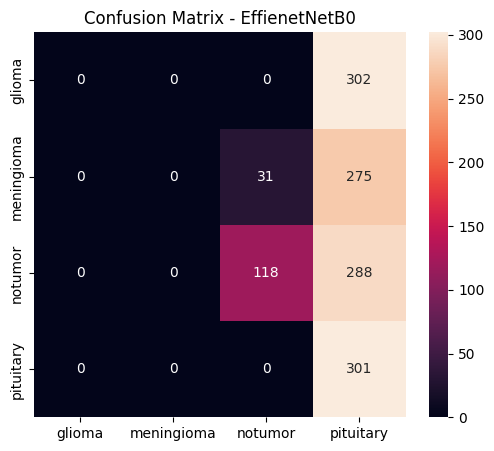

In [13]:
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())
def evaluate_model(model,name):
    y_pred=np.argmax(model.predict(test_gen),axis=1)
    print(f"\n{name} Classification_report")
    print(classification_report(y_true,y_pred, target_names=class_names))
    cm = confusion_matrix(y_true,y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,annot=True,fmt="d",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

evaluate_model(resnet_model, "ResNet50")
evaluate_model(densenet_model, "DenseNet121")
evaluate_model(efficientnet_model, "EffienetNetB0")

In [16]:
def grad_cam(model, img_array, last_conv_layer):
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy(), class_idx.numpy()


In [17]:
def show_gradcam_user_image(image_path, model, last_conv_layer, model_name):
    img = tf.keras.preprocessing.image.load_img(image_path,
                                                 target_size=(224,224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array/255.0, axis=0)

    heatmap, pred_class = grad_cam(model, img_array, last_conv_layer)

    original = cv2.imread(image_path)
    original = cv2.resize(original, (224,224))

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255*heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"{model_name} → {class_names[pred_class]}")
    plt.axis("off")
    plt.show()


In [18]:
LAST_LAYERS = {
    "ResNet50": "conv5_block3_out",
    "DenseNet121": "conv5_block16_concat",
    "EfficientNetB0": "top_conv"
}


Enter MRI image path:  Data set/Testing/meningioma/Te-me_0081.jpg


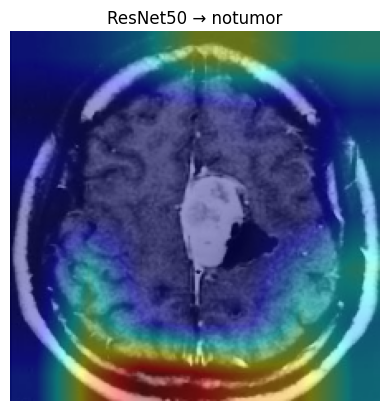

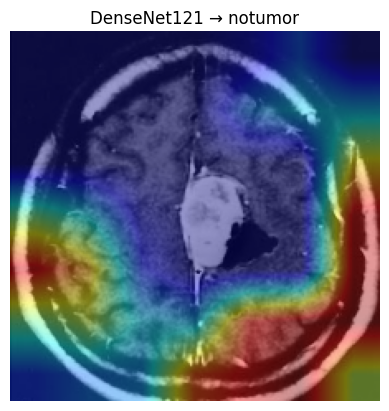

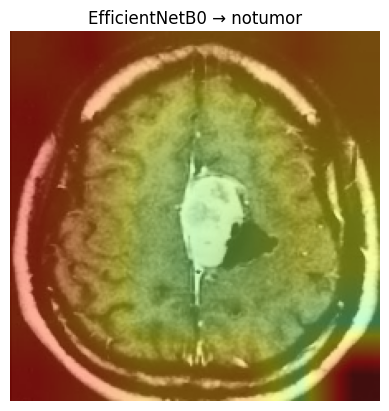

In [21]:
user_image = input("Enter MRI image path: ").strip()

show_gradcam_user_image(user_image, resnet_model,
                        LAST_LAYERS["ResNet50"], "ResNet50")

show_gradcam_user_image(user_image, densenet_model,
                        LAST_LAYERS["DenseNet121"], "DenseNet121")

show_gradcam_user_image(user_image, efficientnet_model,
                        LAST_LAYERS["EfficientNetB0"], "EfficientNetB0")


Enter MRI image path:  Data set/Testing/notumor/Te-no_0188.jpg


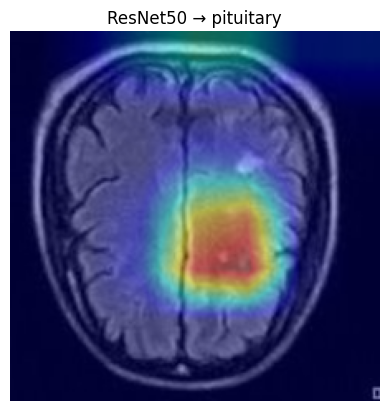

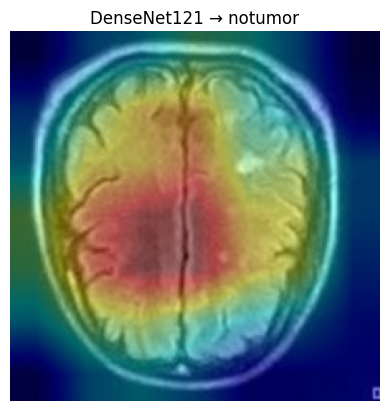

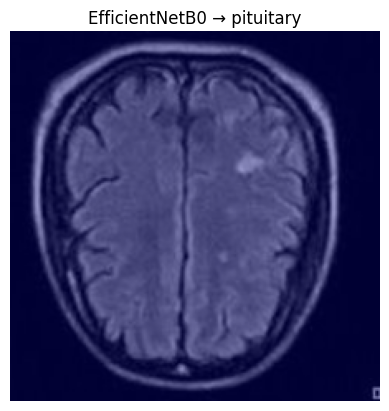

In [22]:
user_image = input("Enter MRI image path: ").strip()

show_gradcam_user_image(user_image, resnet_model,
                        LAST_LAYERS["ResNet50"], "ResNet50")

show_gradcam_user_image(user_image, densenet_model,
                        LAST_LAYERS["DenseNet121"], "DenseNet121")

show_gradcam_user_image(user_image, efficientnet_model,
                        LAST_LAYERS["EfficientNetB0"], "EfficientNetB0")
